# Prediction of Bikecount

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV


from catboost import CatBoostRegressor
from tabpfn import TabPFNRegressor

import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

plt.style.use("tableau-colorblind10")
sns.set_palette("colorblind")


RANDOM_STATE=42
COLORS = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#F0E442', '#56B4E9', '#000000']


## Daten laden

In [2]:
df=pd.read_csv(r"../data/hour.csv")

## Preprocessing- und Feature-Engineering

In [3]:
class DateEncoder(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        if "dteday" in X.columns:
            self.start_date_ = pd.to_datetime(X["dteday"]).min()
        return self

    def transform(self, X):
        df = X.copy()
        if "dteday" not in df.columns:
            return df

        dates = pd.to_datetime(df["dteday"])
        day_of_year  = dates.dt.dayofyear
        day_of_month = dates.dt.day
        hour_of_day=dates.dt.hour

        # Jährliche Saisonalität
        df["dteday_sin_year"] = np.sin(2 * np.pi * day_of_year  / 365.25)
        df["dteday_cos_year"] = np.cos(2 * np.pi * day_of_year  / 365.25)

        # Monatliche Saisonalität (feiner)
        df["dteday_sin_month"] = np.sin(2 * np.pi * day_of_month / 30.44)
        df["dteday_cos_month"] = np.cos(2 * np.pi * day_of_month / 30.44)

        df["dteday_sin_hr"] = np.sin(2 * np.pi * hour_of_day / 24)
        df["dteday_cos_hr"] = np.cos(2 * np.pi * hour_of_day / 24)



        return df.drop(columns=["dteday"])


class BasicPreprocessor(BaseEstimator, TransformerMixin):
    """Drop irrelevanter Spalten (instant, casual, registered)."""
    DROP_COLS = ["instant", "casual", "registered"]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        drop = [c for c in self.DROP_COLS if c in df.columns]
        print(drop)
        return df.drop(columns=drop)

class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """OneHotEncoding für season, weathersit, weekday."""
    CATEGORICAL_COLS = ["season", "weathersit", "weekday"]

    def __init__(self):
        self.encoder_ = None
        self.cat_cols_present_ = None

    def fit(self, X, y=None):
        df = X.copy()
        self.cat_cols_present_ = [c for c in self.CATEGORICAL_COLS if c in df.columns]
        self.encoder_ = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        self.encoder_.fit(df[self.cat_cols_present_])
        return self

    def transform(self, X):
        df = X.copy()
        encoded = self.encoder_.transform(df[self.cat_cols_present_])
        encoded_df = pd.DataFrame(
            encoded,
            columns=self.encoder_.get_feature_names_out(self.cat_cols_present_),
            index=df.index,
        )
        return pd.concat([df.drop(columns=self.cat_cols_present_), encoded_df], axis=1)

class TimeSeriesFeatureEngineer(BaseEstimator, TransformerMixin):
    """Lag-, Rolling- und Differenz-Features."""
    LAGS    = [1, 2, 6, 12, 24]
    WINDOWS = [3, 6, 12, 24]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        """
        for lag in self.LAGS:
            df[f"cnt_lag_{lag}"] = df["cnt"].shift(lag)
        """
        for window in self.WINDOWS:
            rolled = df["cnt"].shift(1).rolling(window)
            df[f"cnt_roll_mean_{window}"] = rolled.mean()
            df[f"cnt_roll_std_{window}"]  = rolled.std()
            df[f"cnt_roll_max_{window}"]  = rolled.max()

        df["cnt_diff_1"]  = df["cnt"].diff(1)
        df["cnt_diff_24"] = df["cnt"].diff(24)

        return df.dropna().reset_index(drop=True)


class DropEncodedFeatures(BaseEstimator, TransformerMixin):
    encoded_cols=["yr","mnth","hr"]
    def fit(self,X,y=None):
        return self

    def transform(self, X, encoded_cols=encoded_cols):
        df=X.copy()
        df=df.drop(columns=encoded_cols)
        return df


In [4]:
def build_pipeline() -> Pipeline:
    return Pipeline(steps=[
        ("date",       DateEncoder()),
        ("basic",      BasicPreprocessor()),
        ("timeseries", TimeSeriesFeatureEngineer()),
        ("ohe",        CategoricalEncoder()),
        ("drop", DropEncodedFeatures())
    ])

In [5]:
pipeline=build_pipeline()
df=pipeline.fit_transform(df)
X=df.drop(columns="cnt")
y=df["cnt"]
X.head()

['instant', 'casual', 'registered']


,holiday,workingday,temp,atemp,hum,windspeed,dteday_sin_year,dteday_cos_year,dteday_sin_month,dteday_cos_month,...,weathersit_2,weathersit_3,weathersit_4,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,0,0,0.46,0.4545,0.88,0.2985,0.034398,0.999408,0.401198,0.915991,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0.44,0.4394,0.94,0.2537,0.034398,0.999408,0.401198,0.915991,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0.42,0.4242,1.00,0.2836,0.034398,0.999408,0.401198,0.915991,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0.46,0.4545,0.94,0.1940,0.034398,0.999408,0.401198,0.915991,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0.46,0.4545,0.94,0.1940,0.034398,0.999408,0.401198,0.915991,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Train-Test-Split

In [6]:
ts_outer = TimeSeriesSplit(n_splits=2, test_size=3400)
outer_splits = list(ts_outer.split(X))
train_idx, test_idx = outer_splits[0]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

ts_cv = TimeSeriesSplit(n_splits=5, test_size=1500)


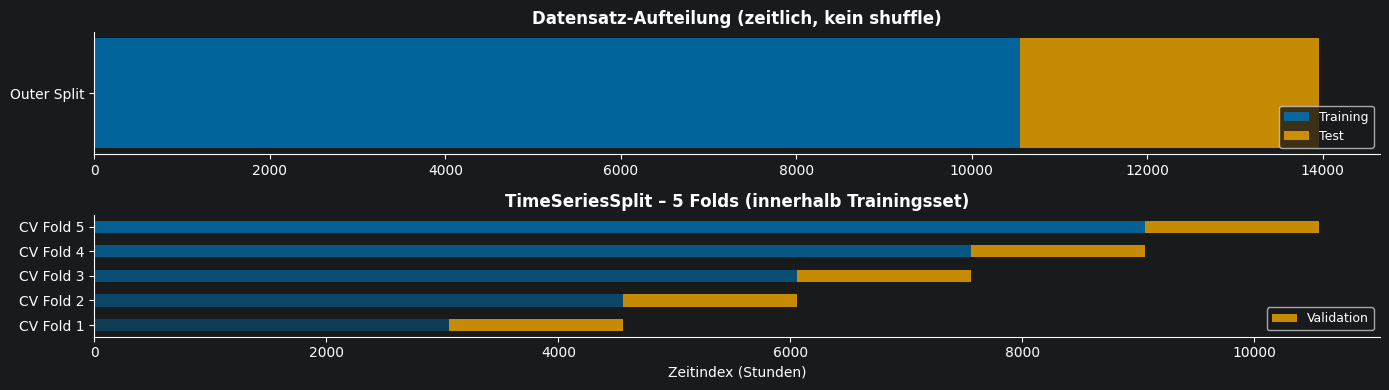

Trainingsset: 10,555 Stunden  |  Testset: 3,400 Stunden  |  Gesamt: 17,355 Stunden


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 4), sharex=False)

# Outer Train/Test Split
ax = axes[0]
ax.barh(0, len(train_idx), left=0, height=0.5, color=COLORS[0], alpha=0.85, label='Training')
ax.barh(0, len(test_idx),  left=len(train_idx), height=0.5, color=COLORS[1], alpha=0.85, label='Test')
ax.set_yticks([0])
ax.set_yticklabels(['Outer Split'])
ax.legend(loc='lower right', fontsize=9)
ax.set_title('Datensatz-Aufteilung (zeitlich, kein shuffle)', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# CV Folds innerhalb des Trainingssets
ax2 = axes[1]
for fold_i, (fold_tr_idx, fold_val_idx) in enumerate(ts_cv.split(X_train)):
    ax2.barh(fold_i, len(fold_tr_idx),  left=0,                height=0.5,
             color=COLORS[0], alpha=0.4 + 0.1 * fold_i)
    ax2.barh(fold_i, len(fold_val_idx), left=len(fold_tr_idx), height=0.5,
             color=COLORS[1], alpha=0.85,
             label='Validation' if fold_i == 0 else '')
ax2.set_yticks(range(5))
ax2.set_yticklabels([f'CV Fold {i+1}' for i in range(5)])
ax2.legend(loc='lower right', fontsize=9)
ax2.set_title('TimeSeriesSplit – 5 Folds (innerhalb Trainingsset)', fontweight='bold')
ax2.set_xlabel('Zeitindex (Stunden)')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
print(f"Trainingsset: {len(train_idx):,} Stunden  |  Testset: {len(test_idx):,} Stunden  |  Gesamt: {len(X):,} Stunden")

## Evaluierung

In [8]:
def compute_metrics(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2':   r2_score(y_true, y_pred),
    }


def cross_validate_ts(model, X_tr, y_tr, cv):
    fold_maes = []
    for fold_train_idx, fold_val_idx in cv.split(X_tr):
        m = copy.deepcopy(model)
        m.fit(X_tr.iloc[fold_train_idx], y_tr.iloc[fold_train_idx])
        preds = m.predict(X_tr.iloc[fold_val_idx])
        fold_maes.append(mean_absolute_error(y_tr.iloc[fold_val_idx], preds))
    return np.mean(fold_maes), np.std(fold_maes)


def plot_predictions(r, y_test, n_plot=300):
    fig, ax = plt.subplots(figsize=(15, 3.5))
    y_true = y_test.values[:n_plot]
    n = min(n_plot, len(r['y_pred']))
    x_axis = range(n)
    ax.fill_between(x_axis, y_true[:n], alpha=0.15,)
    ax.plot(x_axis, y_true[:n],      label='Wahrheit',   lw=1.2, alpha=0.8, color=COLORS[0])
    ax.plot(x_axis, r['y_pred'][:n], label='Vorhersage', lw=1.0, alpha=0.9, color=COLORS[1])
    ax.set_title(
        f"{r['name']}  |  MAE: {r['MAE']:.1f}  RMSE: {r['RMSE']:.1f}  R²: {r['R2']:.3f}",
        fontweight='bold', fontsize=11
    )
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylabel('cnt')
    ax.set_xlabel('Zeitschritt')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


all_results = []

In [9]:
X_train

,holiday,workingday,temp,atemp,hum,windspeed,dteday_sin_year,dteday_cos_year,dteday_sin_month,dteday_cos_month,...,weathersit_2,weathersit_3,weathersit_4,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,0,0,0.46,0.4545,0.88,0.2985,0.034398,0.999408,0.401198,0.915991,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0.44,0.4394,0.94,0.2537,0.034398,0.999408,0.401198,0.915991,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0.42,0.4242,1.00,0.2836,0.034398,0.999408,0.401198,0.915991,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0.46,0.4545,0.94,0.1940,0.034398,0.999408,0.401198,0.915991,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0.46,0.4545,0.94,0.1940,0.034398,0.999408,0.401198,0.915991,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10550,0,1,0.60,0.5909,0.69,0.0896,0.984306,0.176471,-0.929503,-0.368815,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10551,0,1,0.60,0.5909,0.69,0.0000,0.984306,0.176471,-0.929503,-0.368815,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10552,0,1,0.60,0.6061,0.64,0.0000,0.984306,0.176471,-0.929503,-0.368815,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10553,0,1,0.56,0.5303,0.78,0.0896,0.984306,0.176471,-0.929503,-0.368815,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### Begründung der Metriken

| Metrik | Formel (vereinfacht) | Warum geeignet? |
|--------|----------------------|-----------------|
| **MAE** | ∅\|y − ŷ\| | Robust gegenüber Ausreißern; direkt in Einheiten (Fahrten/h) interpretierbar |
| **RMSE** | √(∅(y − ŷ)²) | Bestraft große Fehler stärker; deckt Schwächen bei Spitzenwerten (Rush Hours) auf |
| **R²** | 1 − SS_res / SS_tot | Skalierungsunabhängig; zeigt, wie viel Varianz erklärt wird (1.0 = perfekt) |

Da `cnt` rechtsschief verteilt ist (Nacht ≪ Spitzenstunden) und keine negativen Werte hat, bilden MAE und RMSE gemeinsam die Fehlercharakteristik gut ab.

**Cross-Validation-Strategie:** `TimeSeriesSplit` verhindert Data Leakage, da Validierungsdaten stets zeitlich *nach* den Trainingsdaten liegen.
Der äußere Testssplit bleibt dauerhaft ausgespart und wird erst zur finalen Evaluierung genutzt.

## Modellierung
### Modellierung am Beispiel von Ridge

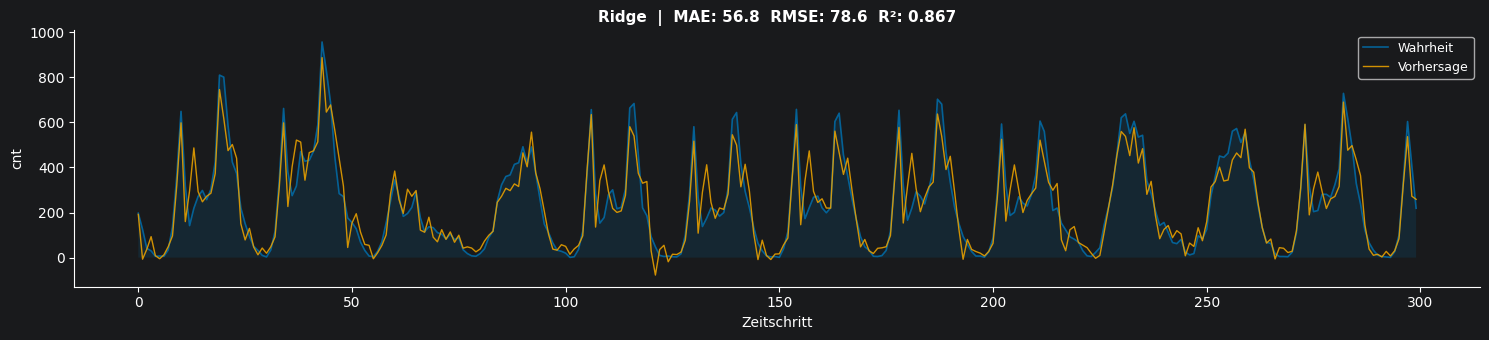

In [10]:

ridge = Ridge(alpha=0.1, random_state=RANDOM_STATE, max_iter=200, fit_intercept=True)
cv_mae, cv_std = cross_validate_ts(ridge, X_train, y_train, ts_cv)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
metrics_ridge = compute_metrics(y_test, y_pred_ridge)

result_ridge = {'name': 'Ridge', 'cv_mae': cv_mae, 'cv_std': cv_std, 'y_pred': y_pred_ridge, **metrics_ridge}
all_results.append(result_ridge)
plot_predictions(result_ridge, y_test)

### Modellierung am Beispiel eines HistGradientBoostingRegressor

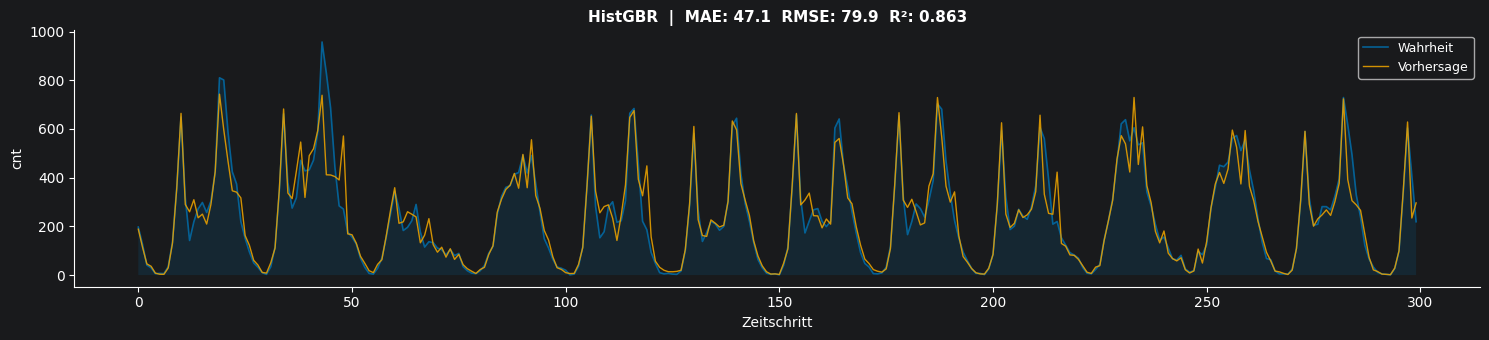

In [12]:
hgb = HistGradientBoostingRegressor(
    max_iter=400,
    learning_rate=0.05,
    max_leaf_nodes=63,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)

cv_mae, cv_std = cross_validate_ts(hgb, X_train, y_train, ts_cv)
hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)
metrics_hgb = compute_metrics(y_test, y_pred_hgb)

result_hgb = {'name': 'HistGBR', 'cv_mae': cv_mae, 'cv_std': cv_std,
              'y_pred': y_pred_hgb, **metrics_hgb}
all_results.append(result_hgb)
plot_predictions(result_hgb, y_test)

### Modellierung am Beispiel eines RandomForestRegressors

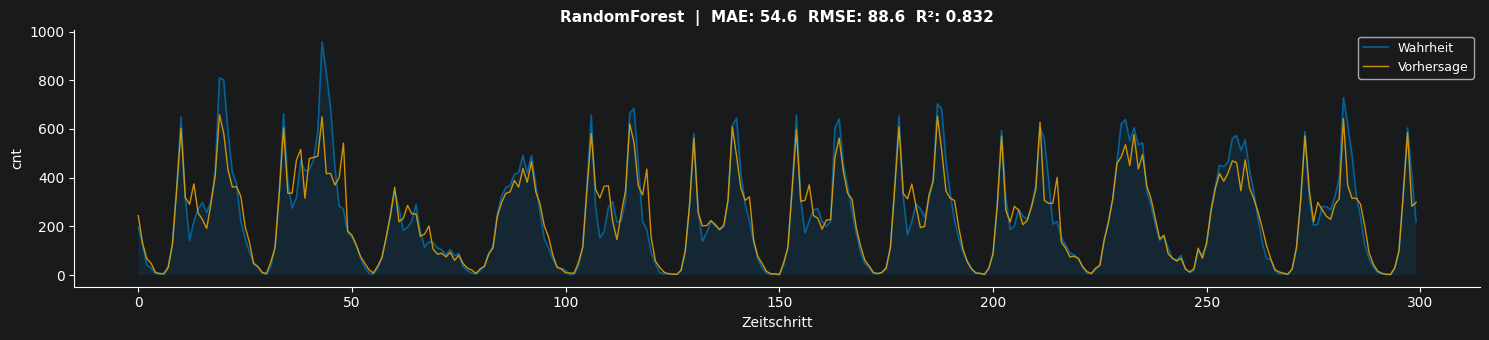

In [14]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    max_features=0.5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

cv_mae, cv_std = cross_validate_ts(rf, X_train, y_train, ts_cv)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
metrics_rf = compute_metrics(y_test, y_pred_rf)

result_rf = {'name': 'RandomForest', 'cv_mae': cv_mae, 'cv_std': cv_std,
             'y_pred': y_pred_rf, **metrics_rf}
all_results.append(result_rf)
plot_predictions(result_rf, y_test)

### Modellierung am Beispiel von CatBoost
#### Warum wird CatBoost verwendet? 

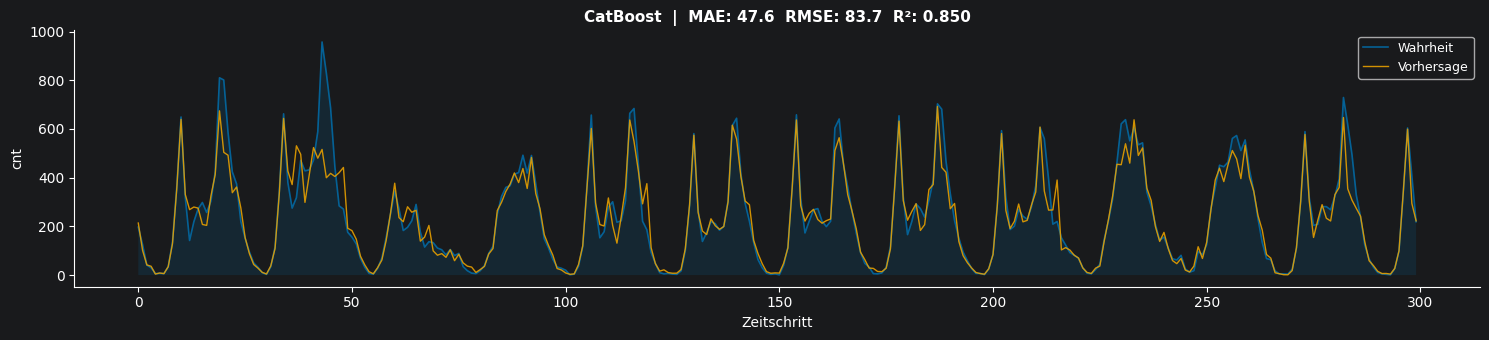

In [16]:
cat_model = CatBoostRegressor(
    iterations=600,
    learning_rate=0.04,
    depth=7,
    min_data_in_leaf=10,
    subsample=0.8,
    random_seed=RANDOM_STATE,
    verbose=0
)

cv_mae, cv_std = cross_validate_ts(cat_model, X_train, y_train, ts_cv)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)
metrics_cat = compute_metrics(y_test, y_pred_cat)

result_cat = {'name': 'CatBoost', 'cv_mae': cv_mae, 'cv_std': cv_std,
              'y_pred': y_pred_cat, **metrics_cat}
all_results.append(result_cat)
plot_predictions(result_cat, y_test)

### Modellierung am Beispiel von TabPFN
#### Was ist TabPFN?
[ToDo]


TabPFN Trainingssubset: 10000 Samples, 41 Features


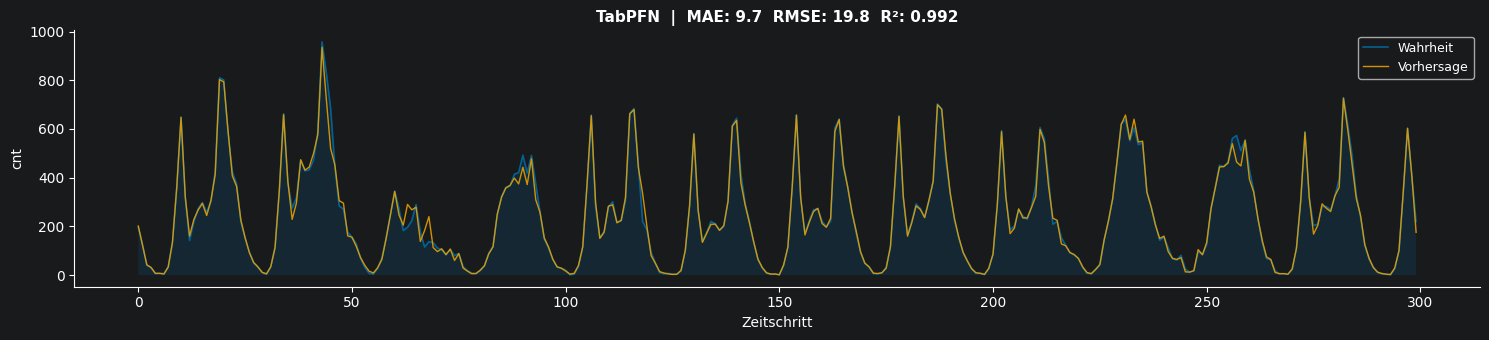

In [18]:
load_dotenv()

os.environ["TABPFN_TOKEN"] = os.getenv("TABPFN_TOKEN")


TABPFN_MAX_TRAIN = 10_000

if len(X_train) > TABPFN_MAX_TRAIN:
    X_train_tab = X_train.iloc[-TABPFN_MAX_TRAIN:]
    y_train_tab = y_train.iloc[-TABPFN_MAX_TRAIN:]
else:
    X_train_tab = X_train
    y_train_tab = y_train

print(f'TabPFN Trainingssubset: {len(X_train_tab)} Samples, {X_train_tab.shape[1]} Features')

tabpfn = TabPFNRegressor(
    n_estimators=8,
    ignore_pretraining_limits=True,
)

# Cross-Validation auf dem Subset
ts_cv_tab = TimeSeriesSplit(n_splits=3, test_size=500)
cv_mae_tab, cv_std_tab = cross_validate_ts(tabpfn, X_train_tab, y_train_tab, ts_cv_tab)

tabpfn.fit(X_train_tab, y_train_tab)
y_pred_tabpfn = tabpfn.predict(X_test)
metrics_tabpfn = compute_metrics(y_test, y_pred_tabpfn)

result_tabpfn = {
    'name':    'TabPFN',
    'cv_mae':  cv_mae_tab,
    'cv_std':  cv_std_tab,
    'y_pred':  y_pred_tabpfn,
    'note':    f'Subset (letzte {len(X_train_tab)} Trainings-Samples)',
    **metrics_tabpfn,
}
all_results.append(result_tabpfn)
plot_predictions(result_tabpfn, y_test)

### Cross-Validation: Fold-Analyse aller Modelle

Die folgende Auswertung zeigt den MAE je Fold für jedes Modell.  
So lässt sich erkennen, ob ein Modell in späteren Folds (= neuere Zeitabschnitte) schlechter wird, was ein Zeichen für mangelnde Generalisierung auf ungesehene Zeiträume ist.

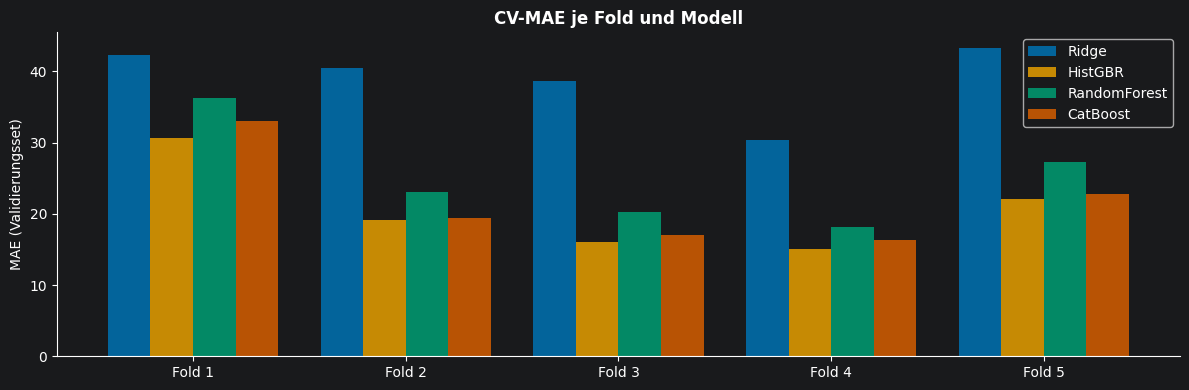

,Ridge,HistGBR,RandomForest,CatBoost
Fold 1,42.35,30.61,36.28,33.01
Fold 2,40.50,19.08,23.02,19.43
Fold 3,38.61,16.00,20.25,17.05
Fold 4,30.34,15.06,18.15,16.31
Fold 5,43.32,22.03,27.24,22.82
Mittelwert,39.02,20.56,24.99,21.72
Std.abw.,4.63,5.59,6.41,6.08


In [19]:
def cross_validate_ts_folds(model, X_tr, y_tr, cv):
    """Gibt MAE je Fold zurück (statt nur Mittelwert und Std.)."""
    fold_maes = []
    for fold_train_idx, fold_val_idx in cv.split(X_tr):
        m = copy.deepcopy(model)
        m.fit(X_tr.iloc[fold_train_idx], y_tr.iloc[fold_train_idx])
        preds = m.predict(X_tr.iloc[fold_val_idx])
        fold_maes.append(mean_absolute_error(y_tr.iloc[fold_val_idx], preds))
    return fold_maes

fold_models = {
    'Ridge':        ridge,
    'HistGBR':      hgb,
    'RandomForest': rf,
    'CatBoost':     cat_model,
}
fold_results = {name: cross_validate_ts_folds(m, X_train, y_train, ts_cv)
                for name, m in fold_models.items()}

n_folds = ts_cv.n_splits
x = np.arange(n_folds)
width = 0.2

fig, ax = plt.subplots(figsize=(12, 4))
for i, (name, maes) in enumerate(fold_results.items()):
    ax.bar(x + i * width, maes, width, label=name, color=COLORS[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'Fold {j+1}' for j in range(n_folds)])
ax.set_ylabel('MAE (Validierungsset)')
ax.set_title('CV-MAE je Fold und Modell', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Zusammenfassung als Tabelle
fold_df = pd.DataFrame(fold_results, index=[f'Fold {i+1}' for i in range(n_folds)])
fold_df.loc['Mittelwert'] = fold_df.mean()
fold_df.loc['Std.abw.']   = fold_df.std()
fold_df.round(2)

## Hyperparameter-Tuning – HistGradientBoostingRegressor

`RandomizedSearchCV` mit `TimeSeriesSplit` (n_splits=3, test_size=1500) durchsucht zufällig 30 Parameterkombinationen.  
Als Scoring-Metrik dient `neg_mean_absolute_error`, da MAE die Vorhersagequalität am direktesten in der Zieleinheit abbildet.

**Suchraum:**

| Parameter | Werte |
|-----------|-------|
| `max_iter` | 200, 400, 600, 800 |
| `learning_rate` | 0.01, 0.03, 0.05, 0.1, 0.15 |
| `max_leaf_nodes` | 31, 63, 127, 255 |
| `min_samples_leaf` | 5, 10, 20, 30 |
| `l2_regularization` | 0.0, 0.1, 1.0, 10.0 |


Beste Hyperparameter:
  min_samples_leaf         : 20
  max_leaf_nodes           : 64
  max_iter                 : 800
  learning_rate            : 0.05
  l2_regularization        : 1.0

Bestes CV-MAE  (Tuning):   -0.94
Baseline CV-MAE (HistGBR): 20.56 ± 5.59


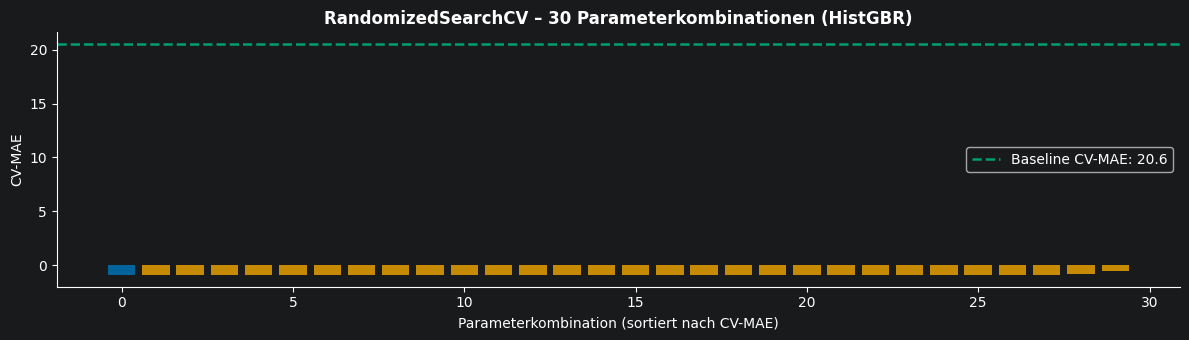

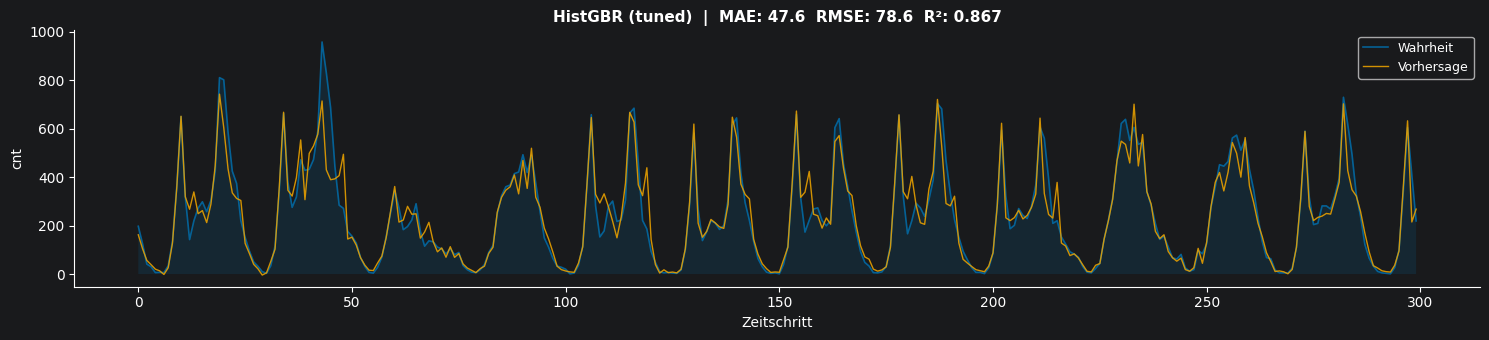


Vergleich Baseline vs. Tuned HistGBR:
  Baseline – MAE: 47.07  RMSE: 79.86  R²: 0.8632
  Tuned    – MAE: 47.57  RMSE: 78.64  R²: 0.8674


In [20]:

param_dist_hgb = {
    'max_iter':          [50,200, 400, 600, 800],
    'learning_rate':     [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    'max_leaf_nodes':    [32, 64, 128, 255],
    'min_samples_leaf':  [5, 10, 20, 30],
    'l2_regularization': [0.0, 0.1, 1.0, 10.0],
}

ts_cv_tuning = TimeSeriesSplit(n_splits=3, test_size=1500)

hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=param_dist_hgb,
    n_iter=30,
    cv=ts_cv_tuning,
    #scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
    refit=True,
)

hgb_search.fit(X_train, y_train)

best_params = hgb_search.best_params_
best_cv_mae = -hgb_search.best_score_

print("\nBeste Hyperparameter:")
for k, v in best_params.items():
    print(f"  {k:25s}: {v}")
print(f"\nBestes CV-MAE  (Tuning):   {best_cv_mae:.2f}")
print(f"Baseline CV-MAE (HistGBR): {result_hgb['cv_mae']:.2f} ± {result_hgb['cv_std']:.2f}")

# Alle 30 Kandidaten visualisieren
cv_df = pd.DataFrame(hgb_search.cv_results_)
cv_df['mean_test_MAE'] = -cv_df['mean_test_score']
cv_df = cv_df.sort_values('mean_test_MAE').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 3.5))
bar_colors = [COLORS[0]] + [COLORS[1]] * (len(cv_df) - 1)
ax.bar(range(len(cv_df)), cv_df['mean_test_MAE'], color=bar_colors, alpha=0.85)
ax.axhline(result_hgb['cv_mae'], color=COLORS[2], ls='--', lw=1.8,
           label=f'Baseline CV-MAE: {result_hgb["cv_mae"]:.1f}')
ax.set_xlabel('Parameterkombination (sortiert nach CV-MAE)')
ax.set_ylabel('CV-MAE')
ax.set_title('RandomizedSearchCV – 30 Parameterkombinationen (HistGBR)', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Testset-Evaluierung des besten Modells
hgb_tuned     = hgb_search.best_estimator_
y_pred_tuned  = hgb_tuned.predict(X_test)
metrics_tuned = compute_metrics(y_test, y_pred_tuned)

result_hgb_tuned = {
    'name':    'HistGBR (tuned)',
    'cv_mae':  best_cv_mae,
    'cv_std':  cv_df['mean_test_MAE'].std(),
    'y_pred':  y_pred_tuned,
    **metrics_tuned,
}
all_results.append(result_hgb_tuned)
plot_predictions(result_hgb_tuned, y_test)

print(f"\nVergleich Baseline vs. Tuned HistGBR:")
print(f"  Baseline – MAE: {result_hgb['MAE']:.2f}  RMSE: {result_hgb['RMSE']:.2f}  R²: {result_hgb['R2']:.4f}")
print(f"  Tuned    – MAE: {metrics_tuned['MAE']:.2f}  RMSE: {metrics_tuned['RMSE']:.2f}  R²: {metrics_tuned['R2']:.4f}")

## Vergleich & Evaluation

In [21]:
rows = []
for r in all_results:
    if r['cv_mae'] is not None:
        cv_str = f"{r['cv_mae']:.1f} ± {r['cv_std']:.1f}"
    else:
        cv_str = f"n/a ({r.get('note', 'Subset')})"
    rows.append({
        'Methode':   r['name'],
        'CV-MAE':    cv_str,
        'Test MAE':  round(r['MAE'], 2),
        'Test RMSE': round(r['RMSE'], 2),
        'Test R²':   round(r['R2'], 4),
        'Hinweis':   r.get('note', '–'),
    })

results_df = pd.DataFrame(rows).sort_values('Test MAE').reset_index(drop=True)
results_df

,Methode,CV-MAE,Test MAE,Test RMSE,Test R²,Hinweis
0,TabPFN,7.0 ± 2.7,9.75,19.80,0.9916,Subset (letzte 10000 Trainings-Samples)
1,HistGBR,20.6 ± 5.6,47.07,79.86,0.8632,–
2,HistGBR (tuned),-0.9 ± 0.1,47.57,78.64,0.8674,–
3,CatBoost,21.7 ± 6.1,47.63,83.66,0.8499,–
4,RandomForest,25.0 ± 6.4,54.59,88.56,0.8318,–
5,Ridge,39.0 ± 4.6,56.80,78.63,0.8674,–


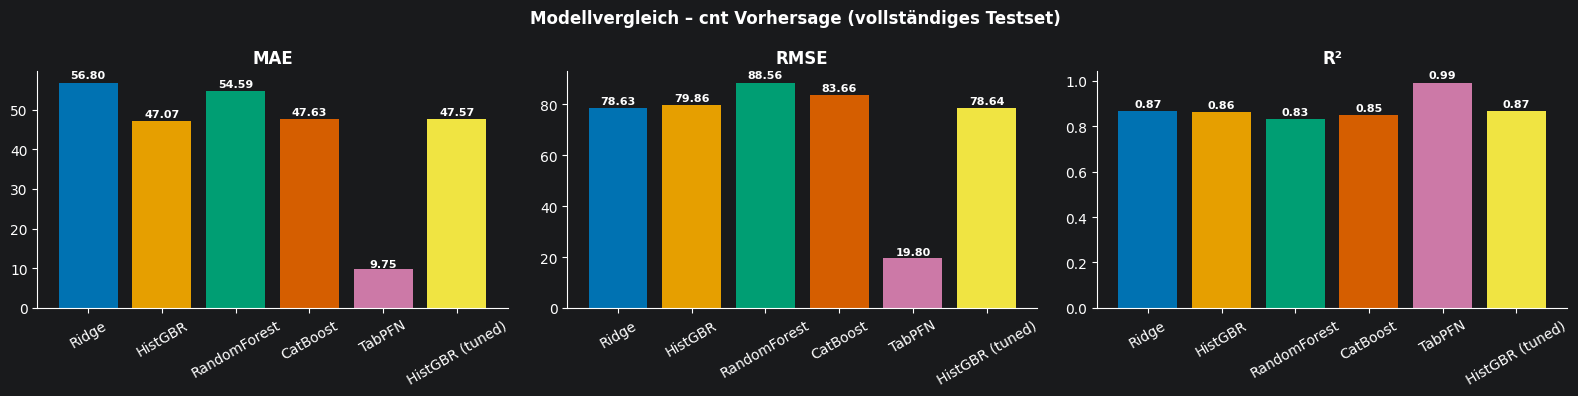

In [22]:

full_results = [r for r in all_results if len(r['y_pred']) >= 300]
names_full   = [r['name'] for r in full_results]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric, label in zip(axes, ['MAE', 'RMSE', 'R2'], ['MAE', 'RMSE', 'R²']):
    vals = [r[metric] for r in full_results]
    bars = ax.bar(names_full, vals, color=COLORS[:len(names_full)], linewidth=0.5)
    ax.set_title(label, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Modellvergleich – cnt Vorhersage (vollständiges Testset)', fontweight='bold')
plt.tight_layout()
plt.show()


#### Ohne Datum
![image.png](attachment:image.png)
#### Mit Datum
![image-2.png](attachment:image-2.png)

### Interpretation der Ergebnisse

## Zusatzbaustein
### Hauptkomponentenanalyse / Primärkomponentenanalyse

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train_scaled)
explained = pca.explained_variance_ratio_

feature_names = X_train.columns[:30] 
num_features = len(feature_names)

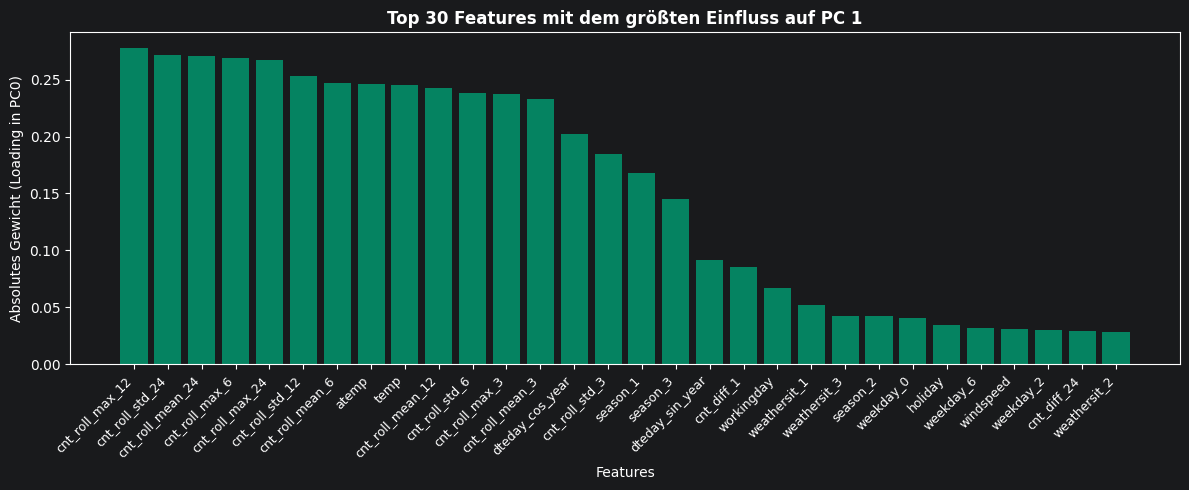

In [24]:
loadings = pca.components_[0]

features_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Absolute Loading': np.abs(loadings) # Absolutwert, da auch negative Gewichte wichtig sind
}).sort_values(by='Absolute Loading', ascending=False).head(30) # Top 30 sortieren

plt.figure(figsize=(12, 5))
plt.bar(features_importance['Feature'], features_importance['Absolute Loading'], color=COLORS[2], alpha=0.8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.xlabel('Features')
plt.ylabel('Absolutes Gewicht (Loading in PC0)')
plt.title('Top 30 Features mit dem größten Einfluss auf PC 1', fontweight='bold')
plt.tight_layout()
plt.show()

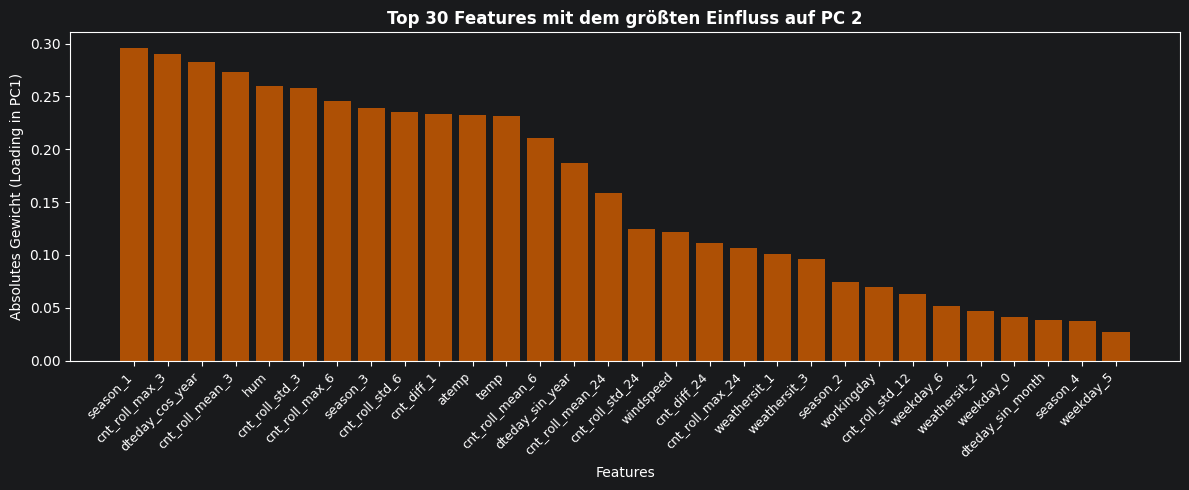

In [25]:
loadings_2 = pca.components_[1]

features_importance_2 = pd.DataFrame({
    'Feature': X_train.columns,
    'Absolute Loading': np.abs(loadings_2) # Absolutwert, da auch negative Gewichte wichtig sind
}).sort_values(by='Absolute Loading', ascending=False).head(30) # Top 30 sortieren

plt.figure(figsize=(12, 5))
plt.bar(features_importance_2['Feature'], features_importance_2['Absolute Loading'], color=COLORS[3], alpha=0.8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.xlabel('Features')
plt.ylabel('Absolutes Gewicht (Loading in PC1)')
plt.title('Top 30 Features mit dem größten Einfluss auf PC 2', fontweight='bold')
plt.tight_layout()
plt.show()


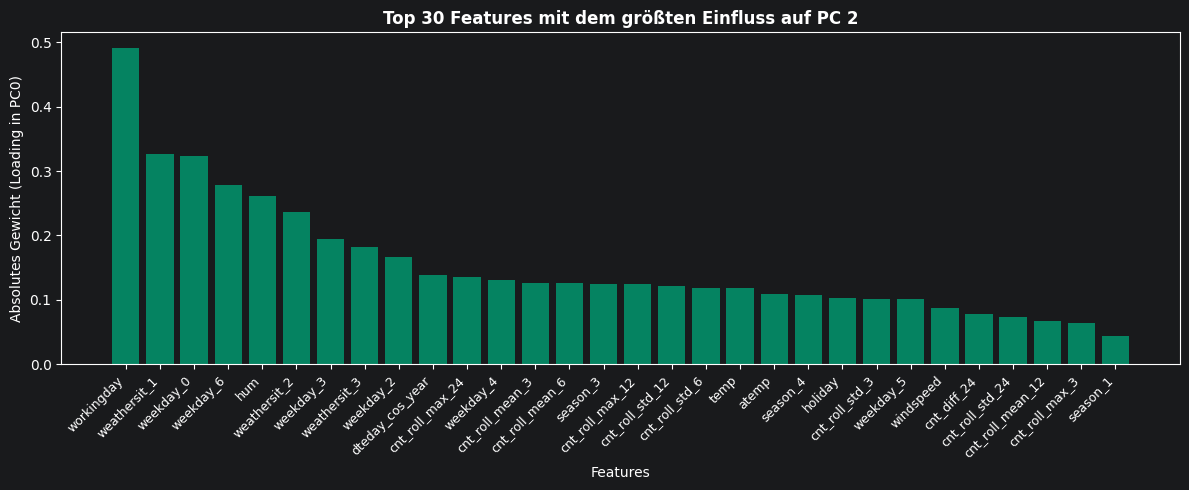

In [26]:
loadings = pca.components_[2]

features_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Absolute Loading': np.abs(loadings) # Absolutwert, da auch negative Gewichte wichtig sind
}).sort_values(by='Absolute Loading', ascending=False).head(30) # Top 30 sortieren

plt.figure(figsize=(12, 5))
plt.bar(features_importance['Feature'], features_importance['Absolute Loading'], color=COLORS[2], alpha=0.8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.xlabel('Features')
plt.ylabel('Absolutes Gewicht (Loading in PC0)')
plt.title('Top 30 Features mit dem größten Einfluss auf PC 2', fontweight='bold')
plt.tight_layout()
plt.show()

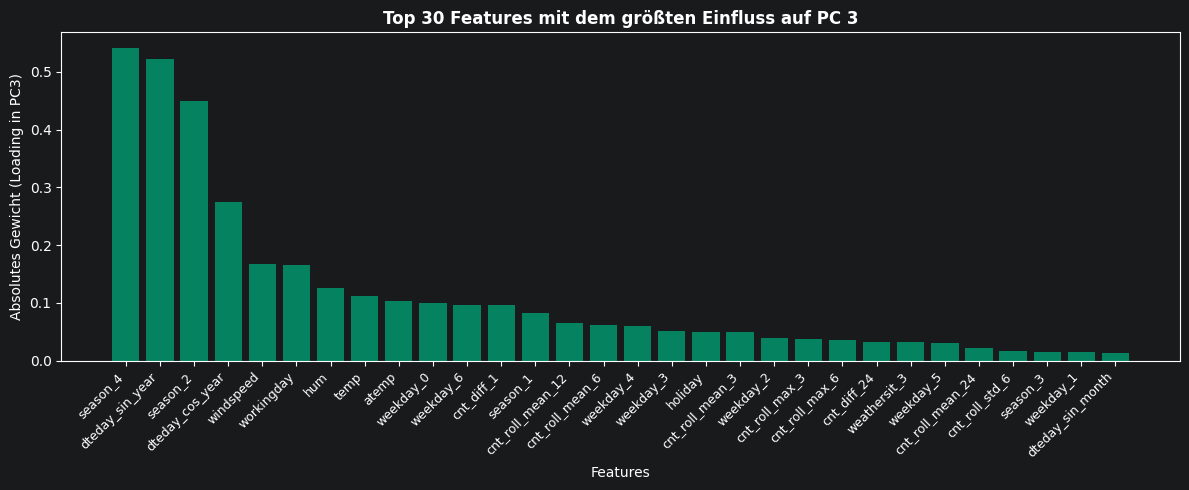

In [27]:
loadings = pca.components_[3]

features_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Absolute Loading': np.abs(loadings) # Absolutwert, da auch negative Gewichte wichtig sind
}).sort_values(by='Absolute Loading', ascending=False).head(30) # Top 30 sortieren

plt.figure(figsize=(12, 5))
plt.bar(features_importance['Feature'], features_importance['Absolute Loading'], color=COLORS[2], alpha=0.8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.xlabel('Features')
plt.ylabel('Absolutes Gewicht (Loading in PC3)')
plt.title('Top 30 Features mit dem größten Einfluss auf PC 3', fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretation der Ergebnisse

### Feature Importance
Feature Importance der Modelle RandomForst und CatBoost. HistGBR und TabPFN besitzen das Attribut `feature_importance_` nicht, daher kann die Feature Importance hier nicht ausgewertet werden. 

In [28]:
TOP_N = 20
feature_names = X_train.columns.tolist()

models_fi = {
    'RandomForest':  rf.feature_importances_,
    'CatBoost':      cat_model.feature_importances_,
}

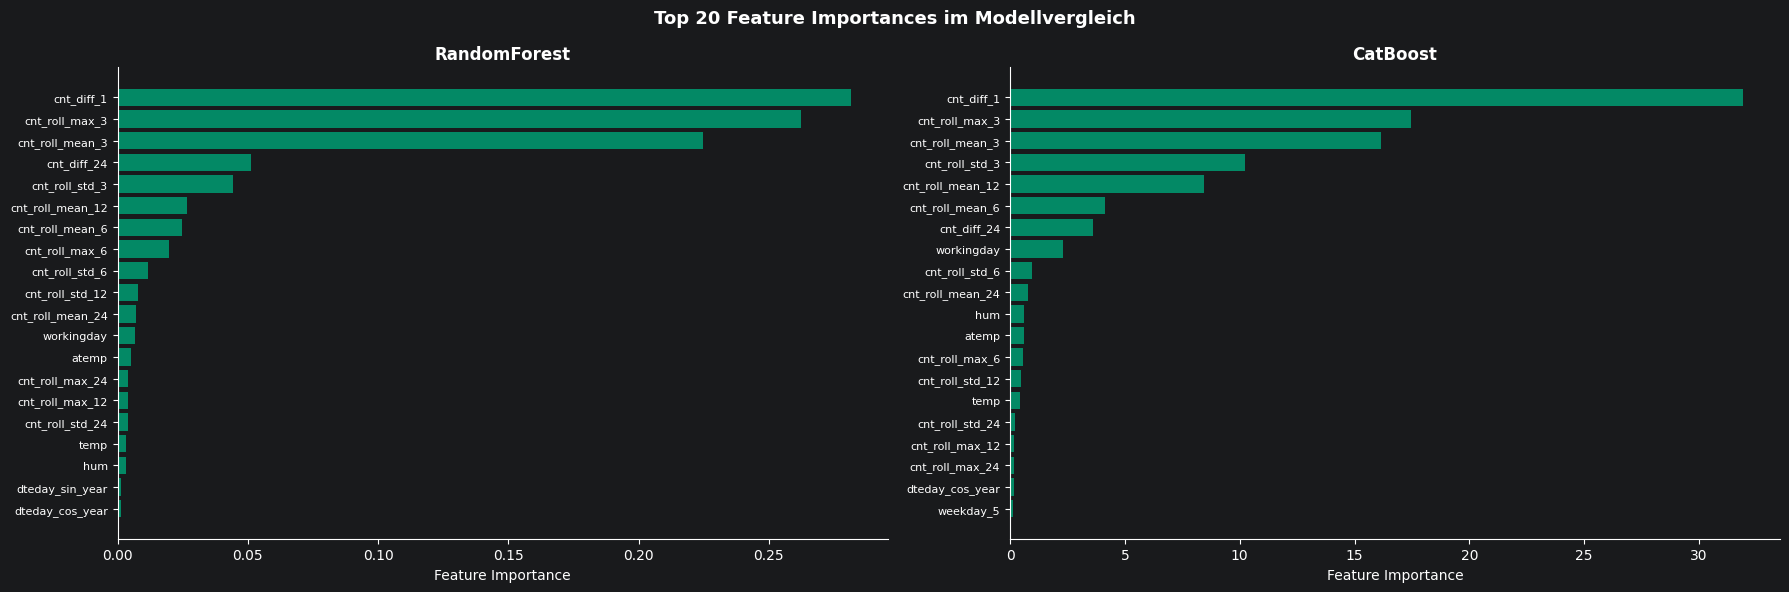

In [29]:

fig, axes = plt.subplots(1, len(models_fi), figsize=(18, 6))

for ax, (model_name, importances) in zip(axes, models_fi.items()):
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    top = fi.head(TOP_N)
    ax.barh(top.index[::-1], top.values[::-1], color=COLORS[2], alpha=0.85)
    ax.set_title(f'{model_name}', fontweight='bold')
    ax.set_xlabel('Feature Importance')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle(f'Top {TOP_N} Feature Importances im Modellvergleich', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

#### Interpretation der Ergebnisse